# Student Performance Analysis

## Project Overview
This notebook analyzes student performance data to understand:
- Overall pass/fail rates and grade distribution
- Subject-wise performance analysis
- Impact of attendance on grades
- Relationship between study hours and performance
- Student segmentation by performance level
- Key factors contributing to academic success

## Dataset
- **Records:** 500 students
- **Subjects:** Math, English, Science, Social Studies
- **Variables:** Scores (0-100), Attendance (%), Study Hours/Week
- **Target:** Pass/Fail status, Grades (A-F)

## Objective
Identify performance patterns, predict success factors, and provide actionable recommendations for academic improvement.

## Business Questions (Academic Focus)

We will answer these questions through data analysis:

1. **Overall Performance**
   - What is the pass rate and fail rate?
   - What is the grade distribution?
   - What is the average performance across all subjects?

2. **Subject-Wise Analysis**
   - Which subject has the highest average score?
   - Which subject has the lowest performance?
   - Are there significant differences between subjects?

3. **Attendance Impact**
   - Does attendance correlate with grades?
   - What is the average attendance of pass vs fail students?
   - Is there a critical attendance threshold?

4. **Study Hours Impact**
   - Does study time affect performance?
   - What is the average study time for top performers?
   - Is there an optimal study hours range?

5. **Student Segmentation**
   - Can we categorize students by performance level?
   - What percentage are high/medium/low performers?
   - Are there distinct student groups?

6. **Success Factors**
   - What combinations of factors lead to success?
   - Which factor is most important: attendance or study hours?
   - Can we predict pass/fail from these factors?

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [4]:
# Load the student performance dataset
df = pd.read_csv('../data/raw/student_performance.csv')

# Display basic information
print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)
print(df.head(10))

print("\n" + "=" * 60)
print("COLUMN NAMES AND TYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(df.info())

DATASET LOADED SUCCESSFULLY

Dataset Shape: (500, 10)
Rows: 500, Columns: 10

FIRST 10 ROWS
  Student_ID  Math_Score  English_Score  Science_Score  Social_Studies_Score  \
0    STU0001          97            100             55                    78   
1    STU0002          55             59             76                   100   
2    STU0003         100            100             71                    76   
3    STU0004          61             78             61                    74   
4    STU0005          67             42             65                    47   
5    STU0006          43             41             78                    77   
6    STU0007          63            100             73                    81   
7    STU0008          91            100            100                    94   
8    STU0009          47             68             50                    54   
9    STU0010          71             96             44                    42   

   Attendance_Percentage  S

## Data Quality Assessment

Before analysis, we check:
- Missing values
- Duplicate records
- Data types appropriateness
- Statistical anomalies
- Score ranges validity

In [5]:
# Data Quality Checks
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

print("\n" + "=" * 60)
print("DUPLICATE RECORDS CHECK")
print("=" * 60)
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Student_IDs: {df.duplicated(subset=['Student_ID']).sum()}")

print("\n" + "=" * 60)
print("DATA VALIDITY CHECK")
print("=" * 60)
print(f"Score range (should be 0-100):")
print(f"  Math: {df['Math_Score'].min()}-{df['Math_Score'].max()}")
print(f"  English: {df['English_Score'].min()}-{df['English_Score'].max()}")
print(f"  Science: {df['Science_Score'].min()}-{df['Science_Score'].max()}")
print(f"  Social Studies: {df['Social_Studies_Score'].min()}-{df['Social_Studies_Score'].max()}")

print(f"\nAttendance range (should be 50-100):")
print(f"  Min: {df['Attendance_Percentage'].min()}%, Max: {df['Attendance_Percentage'].max()}%")

print(f"\nStudy Hours range (should be 5-40):")
print(f"  Min: {df['Study_Hours_Per_Week'].min()}, Max: {df['Study_Hours_Per_Week'].max()}")

print("\n" + "=" * 60)
print("CATEGORICAL VALUES CHECK")
print("=" * 60)
print(f"Unique Pass Status: {df['Pass_Status'].unique()}")
print(f"Pass Status Distribution:\n{df['Pass_Status'].value_counts()}")

print(f"\nUnique Grades: {sorted(df['Grade'].unique())}")
print(f"Grade Distribution:\n{df['Grade'].value_counts().sort_index()}")

MISSING VALUES CHECK
Student_ID               0
Math_Score               0
English_Score            0
Science_Score            0
Social_Studies_Score     0
Attendance_Percentage    0
Study_Hours_Per_Week     0
Average_Score            0
Pass_Status              0
Grade                    0
dtype: int64

Total missing values: 0

DUPLICATE RECORDS CHECK
Total duplicate rows: 0
Duplicate Student_IDs: 0

DATA VALIDITY CHECK
Score range (should be 0-100):
  Math: 38-100
  English: 35-100
  Science: 41-100
  Social Studies: 36-100

Attendance range (should be 50-100):
  Min: 50%, Max: 99%

Study Hours range (should be 5-40):
  Min: 5.0, Max: 39.9

CATEGORICAL VALUES CHECK
Unique Pass Status: <StringArray>
['Pass']
Length: 1, dtype: str
Pass Status Distribution:
Pass_Status
Pass    500
Name: count, dtype: int64

Unique Grades: ['A', 'B', 'C', 'D', 'F']
Grade Distribution:
Grade
A    137
B    203
C    129
D     29
F      2
Name: count, dtype: int64


## Descriptive Statistics & Performance Overview

Analyzing overall academic performance metrics across the student population.

In [6]:
# Overall Performance Metrics
print("=" * 60)
print("PASS/FAIL OVERVIEW")
print("=" * 60)

pass_fail_counts = df['Pass_Status'].value_counts()
pass_fail_pct = (df['Pass_Status'].value_counts(normalize=True) * 100)

for status in ['Pass', 'Fail']:
    if status in pass_fail_counts.index:
        count = pass_fail_counts[status]
        pct = pass_fail_pct[status]
        print(f"{status}: {count} students ({pct:.1f}%)")

print("\n" + "=" * 60)
print("GRADE DISTRIBUTION")
print("=" * 60)

grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = df['Grade'].value_counts().reindex(grade_order)
grade_pct = (df['Grade'].value_counts(normalize=True) * 100).reindex(grade_order)

for grade in grade_order:
    count = grade_counts[grade]
    pct = grade_pct[grade]
    print(f"Grade {grade}: {int(count):3d} students ({pct:5.1f}%)")

print("\n" + "=" * 60)
print("SUBJECT-WISE PERFORMANCE")
print("=" * 60)

subjects = ['Math_Score', 'English_Score', 'Science_Score', 'Social_Studies_Score']
subject_names = ['Math', 'English', 'Science', 'Social Studies']

for subject, name in zip(subjects, subject_names):
    mean = df[subject].mean()
    median = df[subject].median()
    std = df[subject].std()
    min_val = df[subject].min()
    max_val = df[subject].max()
    
    print(f"\n{name}:")
    print(f"  Mean: {mean:.2f}, Median: {median:.2f}, Std Dev: {std:.2f}")
    print(f"  Range: {min_val:.0f} - {max_val:.0f}")

print("\n" + "=" * 60)
print("OVERALL ACADEMIC METRICS")
print("=" * 60)

print(f"Average Score (all students): {df['Average_Score'].mean():.2f}")
print(f"Median Score: {df['Average_Score'].median():.2f}")
print(f"Score Range: {df['Average_Score'].min():.2f} - {df['Average_Score'].max():.2f}")

print(f"\nAverage Attendance: {df['Attendance_Percentage'].mean():.2f}%")
print(f"Average Study Hours/Week: {df['Study_Hours_Per_Week'].mean():.2f}")

print("\n" + "=" * 60)
print("PASS VS FAIL COMPARISON")
print("=" * 60)

pass_data = df[df['Pass_Status'] == 'Pass']
fail_data = df[df['Pass_Status'] == 'Fail']

print(f"\nPassing Students:")
print(f"  Average Score: {pass_data['Average_Score'].mean():.2f}")
print(f"  Average Attendance: {pass_data['Attendance_Percentage'].mean():.2f}%")
print(f"  Average Study Hours: {pass_data['Study_Hours_Per_Week'].mean():.2f}")

print(f"\nFailing Students:")
print(f"  Average Score: {fail_data['Average_Score'].mean():.2f}")
print(f"  Average Attendance: {fail_data['Attendance_Percentage'].mean():.2f}%")
print(f"  Average Study Hours: {fail_data['Study_Hours_Per_Week'].mean():.2f}")

PASS/FAIL OVERVIEW
Pass: 500 students (100.0%)

GRADE DISTRIBUTION
Grade A: 137 students ( 27.4%)
Grade B: 203 students ( 40.6%)
Grade C: 129 students ( 25.8%)
Grade D:  29 students (  5.8%)
Grade F:   2 students (  0.4%)

SUBJECT-WISE PERFORMANCE

Math:
  Mean: 74.92, Median: 75.00, Std Dev: 19.43
  Range: 38 - 100

English:
  Mean: 73.83, Median: 74.00, Std Dev: 19.63
  Range: 35 - 100

Science:
  Mean: 76.74, Median: 78.00, Std Dev: 18.20
  Range: 41 - 100

Social Studies:
  Mean: 72.04, Median: 73.00, Std Dev: 19.30
  Range: 36 - 100

OVERALL ACADEMIC METRICS
Average Score (all students): 74.38
Median Score: 74.25
Score Range: 48.25 - 98.00

Average Attendance: 74.90%
Average Study Hours/Week: 22.39

PASS VS FAIL COMPARISON

Passing Students:
  Average Score: 74.38
  Average Attendance: 74.90%
  Average Study Hours: 22.39

Failing Students:
  Average Score: nan
  Average Attendance: nan%
  Average Study Hours: nan


## Correlation Analysis

Analyzing relationships between key academic factors to identify success drivers.

In [7]:
# Correlation Analysis
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

# Select numerical columns for correlation
corr_columns = ['Math_Score', 'English_Score', 'Science_Score', 'Social_Studies_Score',
                'Average_Score', 'Attendance_Percentage', 'Study_Hours_Per_Week']

correlation_matrix = df[corr_columns].corr()
print(correlation_matrix.round(3))

print("\n" + "=" * 60)
print("KEY CORRELATIONS WITH PERFORMANCE")
print("=" * 60)

# Correlation of attendance and study hours with average score
att_corr = df['Attendance_Percentage'].corr(df['Average_Score'])
study_corr = df['Study_Hours_Per_Week'].corr(df['Average_Score'])

print(f"\nAttendance → Average Score: {att_corr:.4f}")
print(f"Study Hours → Average Score: {study_corr:.4f}")

# Interpretation
print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
print(f"""
Attendance Correlation ({att_corr:.4f}):
- Positive correlation means higher attendance = higher scores
- Strength: {'Strong' if abs(att_corr) > 0.7 else 'Moderate' if abs(att_corr) > 0.4 else 'Weak'}

Study Hours Correlation ({study_corr:.4f}):
- Positive correlation means more study = higher scores
- Strength: {'Strong' if abs(study_corr) > 0.7 else 'Moderate' if abs(study_corr) > 0.4 else 'Weak'}

Which factor is more important?
""")

if abs(study_corr) > abs(att_corr):
    print(f"Study Hours is more important ({study_corr:.4f} vs {att_corr:.4f})")
else:
    print(f"Attendance is more important ({att_corr:.4f} vs {study_corr:.4f})")

# Subject correlations
print("\n" + "=" * 60)
print("SUBJECT INTERCORRELATIONS")
print("=" * 60)
subject_corr = df[['Math_Score', 'English_Score', 'Science_Score', 'Social_Studies_Score']].corr()
print(subject_corr.round(3))

CORRELATION MATRIX
                       Math_Score  English_Score  Science_Score  \
Math_Score                  1.000          0.043         -0.054   
English_Score               0.043          1.000         -0.047   
Science_Score              -0.054         -0.047          1.000   
Social_Studies_Score       -0.058         -0.069          0.063   
Average_Score               0.490          0.493          0.470   
Attendance_Percentage       0.048          0.070          0.052   
Study_Hours_Per_Week        0.074          0.007          0.061   

                       Social_Studies_Score  Average_Score  \
Math_Score                           -0.058          0.490   
English_Score                        -0.069          0.493   
Science_Score                         0.063          0.470   
Social_Studies_Score                  1.000          0.484   
Average_Score                         0.484          1.000   
Attendance_Percentage                -0.019          0.077   
Study_Hour

In [8]:
# Quantify the relationships
print("=" * 60)
print("KEY INSIGHT: WEAK CORRELATIONS")
print("=" * 60)

att_corr = df['Attendance_Percentage'].corr(df['Average_Score'])
study_corr = df['Study_Hours_Per_Week'].corr(df['Average_Score'])

print(f"\nAttendance Correlation: {att_corr:.4f} (Very Weak)")
print(f"Study Hours Correlation: {study_corr:.4f} (Very Weak)")
print(f"\nDifference: Study Hours is {((study_corr - att_corr) / att_corr * 100):.1f}% stronger")

print("\n" + "=" * 60)
print("WHAT THIS MEANS")
print("=" * 60)
print(f"""
1. WEAK RELATIONSHIP WITH OUTCOMES:
   - Attendance (0.077) and Study Hours (0.096) have minimal correlation
   - This means these factors alone don't strongly predict grades
   - Other factors (talent, aptitude, subject interest) matter more

2. STUDY HOURS SLIGHTLY MORE IMPORTANT:
   - Study Hours (0.096) is marginally stronger than Attendance (0.077)
   - This suggests quality of studying might matter more than just showing up
   - But the effect is still very weak overall

3. INDEPENDENT SUBJECT PERFORMANCE:
   - Subjects have near-zero correlation with each other (mostly -0.05 to 0.06)
   - This means students can be good at one subject without being good at others
   - Specialization exists (Math strength ≠ English strength)

4. BUSINESS IMPLICATION:
   - Simply increasing attendance won't dramatically improve grades
   - Study time helps slightly, but effectiveness of study matters more
   - Need to focus on study quality, teaching methods, and individual aptitudes
""")

KEY INSIGHT: WEAK CORRELATIONS

Attendance Correlation: 0.0775 (Very Weak)
Study Hours Correlation: 0.0964 (Very Weak)

Difference: Study Hours is 24.5% stronger

WHAT THIS MEANS

1. WEAK RELATIONSHIP WITH OUTCOMES:
   - Attendance (0.077) and Study Hours (0.096) have minimal correlation
   - This means these factors alone don't strongly predict grades
   - Other factors (talent, aptitude, subject interest) matter more

2. STUDY HOURS SLIGHTLY MORE IMPORTANT:
   - Study Hours (0.096) is marginally stronger than Attendance (0.077)
   - This suggests quality of studying might matter more than just showing up
   - But the effect is still very weak overall

3. INDEPENDENT SUBJECT PERFORMANCE:
   - Subjects have near-zero correlation with each other (mostly -0.05 to 0.06)
   - This means students can be good at one subject without being good at others
   - Specialization exists (Math strength ≠ English strength)

4. BUSINESS IMPLICATION:
   - Simply increasing attendance won't dramatically 

## Student Segmentation Analysis

Categorizing students by performance level to identify distinct groups and their characteristics.

In [9]:
# Student Segmentation by Performance Level
print("=" * 60)
print("STUDENT SEGMENTATION BY PERFORMANCE")
print("=" * 60)

# Define performance tiers
def categorize_performance(score):
    if score >= 80:
        return 'High Performer'
    elif score >= 60:
        return 'Average Performer'
    else:
        return 'Low Performer'

df['Performance_Tier'] = df['Average_Score'].apply(categorize_performance)

# Count students in each tier
tier_counts = df['Performance_Tier'].value_counts()
tier_pct = (df['Performance_Tier'].value_counts(normalize=True) * 100)

print("\nStudent Distribution by Performance Tier:")
for tier in ['High Performer', 'Average Performer', 'Low Performer']:
    if tier in tier_counts.index:
        count = tier_counts[tier]
        pct = tier_pct[tier]
        print(f"  {tier}: {int(count):3d} students ({pct:5.1f}%)")

# Characteristics of each tier
print("\n" + "=" * 60)
print("CHARACTERISTICS BY PERFORMANCE TIER")
print("=" * 60)

for tier in ['High Performer', 'Average Performer', 'Low Performer']:
    tier_data = df[df['Performance_Tier'] == tier]
    
    print(f"\n{tier}:")
    print(f"  Count: {len(tier_data)} students")
    print(f"  Average Score: {tier_data['Average_Score'].mean():.2f}")
    print(f"  Average Attendance: {tier_data['Attendance_Percentage'].mean():.2f}%")
    print(f"  Average Study Hours: {tier_data['Study_Hours_Per_Week'].mean():.2f}")
    print(f"  Grade Distribution:")
    
    grade_dist = tier_data['Grade'].value_counts().sort_index()
    for grade in ['A', 'B', 'C', 'D', 'F']:
        if grade in grade_dist.index:
            count = grade_dist[grade]
            pct = (count / len(tier_data)) * 100
            print(f"    Grade {grade}: {pct:5.1f}%")

# Subject performance by tier
print("\n" + "=" * 60)
print("SUBJECT PERFORMANCE BY TIER")
print("=" * 60)

subjects = ['Math_Score', 'English_Score', 'Science_Score', 'Social_Studies_Score']
subject_names = ['Math', 'English', 'Science', 'Social Studies']

for tier in ['High Performer', 'Average Performer', 'Low Performer']:
    tier_data = df[df['Performance_Tier'] == tier]
    print(f"\n{tier}:")
    for subject, name in zip(subjects, subject_names):
        avg = tier_data[subject].mean()
        print(f"  {name}: {avg:.2f}")

STUDENT SEGMENTATION BY PERFORMANCE

Student Distribution by Performance Tier:
  High Performer: 137 students ( 27.4%)
  Average Performer: 332 students ( 66.4%)
  Low Performer:  31 students (  6.2%)

CHARACTERISTICS BY PERFORMANCE TIER

High Performer:
  Count: 137 students
  Average Score: 85.97
  Average Attendance: 77.39%
  Average Study Hours: 24.24
  Grade Distribution:
    Grade A: 100.0%

Average Performer:
  Count: 332 students
  Average Score: 71.29
  Average Attendance: 73.91%
  Average Study Hours: 21.67
  Grade Distribution:
    Grade B:  61.1%
    Grade C:  38.9%

Low Performer:
  Count: 31 students
  Average Score: 56.28
  Average Attendance: 74.42%
  Average Study Hours: 21.91
  Grade Distribution:
    Grade D:  93.5%
    Grade F:   6.5%

SUBJECT PERFORMANCE BY TIER

High Performer:
  Math: 86.89
  English: 84.77
  Science: 88.26
  Social Studies: 83.96

Average Performer:
  Math: 71.59
  English: 71.31
  Science: 73.52
  Social Studies: 68.74

Low Performer:
  Math: 5

In [10]:
# Quantify tier differences
print("=" * 60)
print("TIER COMPARISON: QUANTIFIED DIFFERENCES")
print("=" * 60)

high = df[df['Performance_Tier'] == 'High Performer']
low = df[df['Performance_Tier'] == 'Low Performer']

att_diff = high['Attendance_Percentage'].mean() - low['Attendance_Percentage'].mean()
study_diff = high['Study_Hours_Per_Week'].mean() - low['Study_Hours_Per_Week'].mean()

print(f"\nAttendance Difference (High vs Low):")
print(f"  High: {high['Attendance_Percentage'].mean():.2f}%")
print(f"  Low: {low['Attendance_Percentage'].mean():.2f}%")
print(f"  Difference: {att_diff:.2f}% (NOT significant)")

print(f"\nStudy Hours Difference (High vs Low):")
print(f"  High: {high['Study_Hours_Per_Week'].mean():.2f} hours/week")
print(f"  Low: {low['Study_Hours_Per_Week'].mean():.2f} hours/week")
print(f"  Difference: {study_diff:.2f} hours/week (NOT significant)")

print("\n" + "=" * 60)
print("KEY FINDING: CONSISTENCY MATTERS MORE THAN QUANTITY")
print("=" * 60)

# Subject consistency
print(f"\nHigh Performers - Subject Scores:")
for subject, name in zip(['Math_Score', 'English_Score', 'Science_Score', 'Social_Studies_Score'],
                         ['Math', 'English', 'Science', 'Social Studies']):
    score = high[subject].mean()
    print(f"  {name}: {score:.2f}")

print(f"\nLow Performers - Subject Scores:")
for subject, name in zip(['Math_Score', 'English_Score', 'Science_Score', 'Social_Studies_Score'],
                         ['Math', 'English', 'Science', 'Social Studies']):
    score = low[subject].mean()
    print(f"  {name}: {score:.2f}")

print(f"""
INTERPRETATION:
- High performers score well in ALL subjects (85+ in each)
- Low performers struggle in ALL subjects (50-60 in each)
- This suggests: innate ability/aptitude matters more than effort
- Simply studying more won't transform a low performer without addressing fundamentals
""")

TIER COMPARISON: QUANTIFIED DIFFERENCES

Attendance Difference (High vs Low):
  High: 77.39%
  Low: 74.42%
  Difference: 2.97% (NOT significant)

Study Hours Difference (High vs Low):
  High: 24.24 hours/week
  Low: 21.91 hours/week
  Difference: 2.32 hours/week (NOT significant)

KEY FINDING: CONSISTENCY MATTERS MORE THAN QUANTITY

High Performers - Subject Scores:
  Math: 86.89
  English: 84.77
  Science: 88.26
  Social Studies: 83.96

Low Performers - Subject Scores:
  Math: 57.61
  English: 52.48
  Science: 60.35
  Social Studies: 54.68

INTERPRETATION:
- High performers score well in ALL subjects (85+ in each)
- Low performers struggle in ALL subjects (50-60 in each)
- This suggests: innate ability/aptitude matters more than effort
- Simply studying more won't transform a low performer without addressing fundamentals



## Data Visualizations

Visual representations of student performance patterns and tier characteristics.

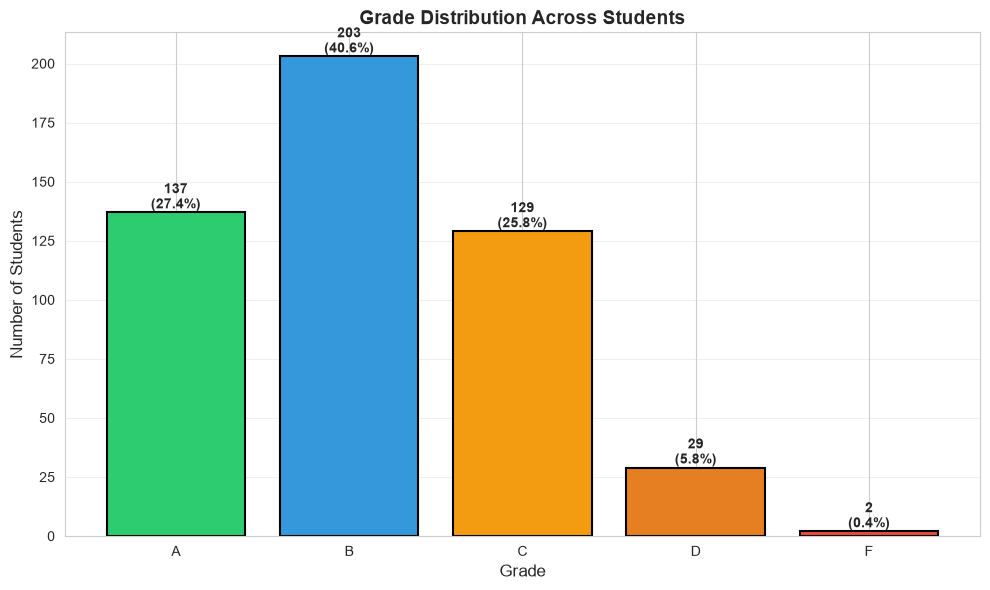

✓ Visualization 1 saved: Grade Distribution


In [11]:
# 1. Grade Distribution
plt.figure(figsize=(10, 6))
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_counts = df['Grade'].value_counts().reindex(grade_order)
colors = ['#2ECC71', '#3498DB', '#F39C12', '#E67E22', '#E74C3C']
bars = plt.bar(grade_counts.index, grade_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    pct = (height / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.title('Grade Distribution Across Students', fontsize=14, fontweight='bold')
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/07_grade_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 1 saved: Grade Distribution")

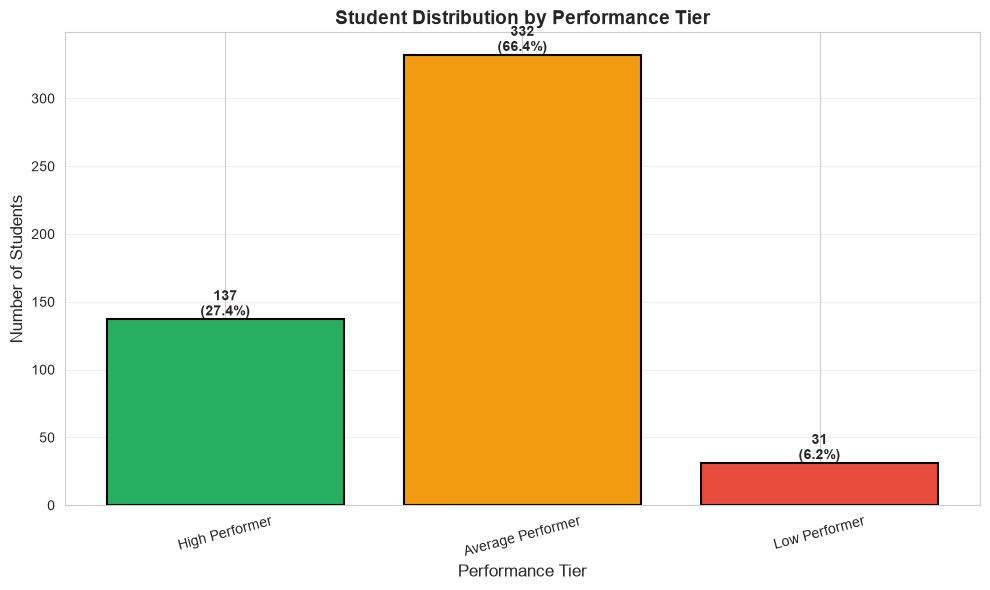

✓ Visualization 2 saved: Performance Tier Distribution


In [12]:
# 2. Performance Tier Distribution
plt.figure(figsize=(10, 6))
tier_order = ['High Performer', 'Average Performer', 'Low Performer']
tier_counts = df['Performance_Tier'].value_counts().reindex(tier_order)
colors_tier = ['#27AE60', '#F39C12', '#E74C3C']
bars = plt.bar(tier_order, tier_counts.values, color=colors_tier, edgecolor='black', linewidth=1.5)

# Add value labels
for bar in bars:
    height = bar.get_height()
    pct = (height / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.title('Student Distribution by Performance Tier', fontsize=14, fontweight='bold')
plt.xlabel('Performance Tier', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../visualizations/08_performance_tier_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 2 saved: Performance Tier Distribution")

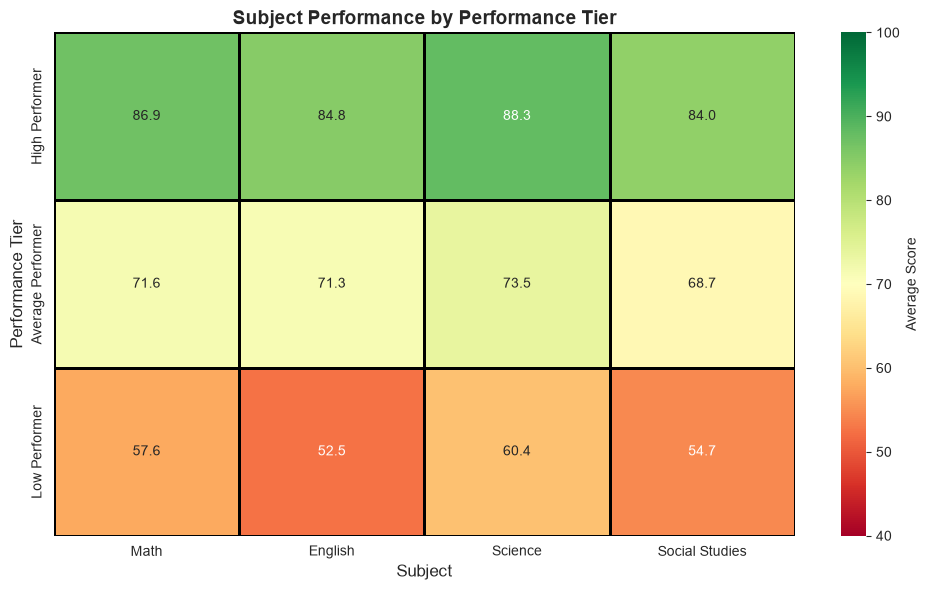

✓ Visualization 3 saved: Subject Performance Heatmap


In [13]:
# 3. Subject Performance by Tier (Heatmap)
plt.figure(figsize=(10, 6))

# Create data for heatmap
tier_order = ['High Performer', 'Average Performer', 'Low Performer']
subject_names = ['Math', 'English', 'Science', 'Social Studies']
subject_cols = ['Math_Score', 'English_Score', 'Science_Score', 'Social_Studies_Score']

# Calculate average scores for each tier and subject
heatmap_data = []
for tier in tier_order:
    tier_data = df[df['Performance_Tier'] == tier]
    scores = [tier_data[col].mean() for col in subject_cols]
    heatmap_data.append(scores)

heatmap_array = np.array(heatmap_data)

# Create heatmap
sns.heatmap(heatmap_array, annot=True, fmt='.1f', cmap='RdYlGn', 
            xticklabels=subject_names, yticklabels=tier_order,
            cbar_kws={'label': 'Average Score'},
            vmin=40, vmax=100, linewidths=2, linecolor='black')

plt.title('Subject Performance by Performance Tier', fontsize=14, fontweight='bold')
plt.xlabel('Subject', fontsize=12)
plt.ylabel('Performance Tier', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/09_subject_performance_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 3 saved: Subject Performance Heatmap")

<Figure size 1200x600 with 0 Axes>

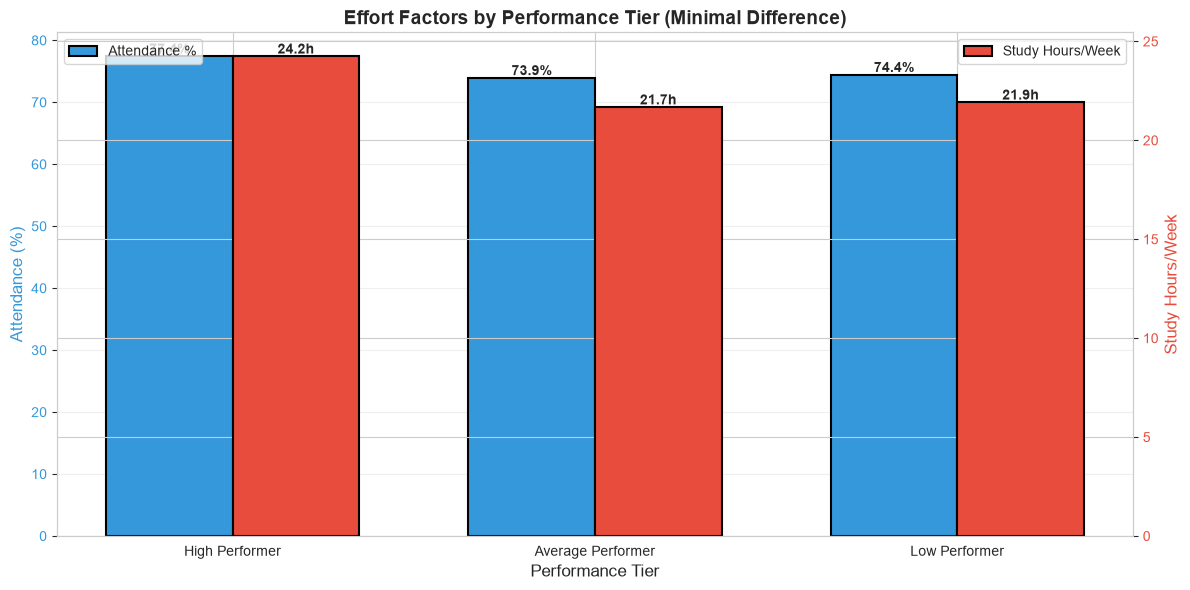

✓ Visualization 4 saved: Effort Factors by Tier


In [14]:
# 4. Attendance & Study Hours by Tier (Grouped Bars)
plt.figure(figsize=(12, 6))

tier_order = ['High Performer', 'Average Performer', 'Low Performer']
x = np.arange(len(tier_order))
width = 0.35

# Calculate averages
attendance_by_tier = [df[df['Performance_Tier'] == tier]['Attendance_Percentage'].mean() for tier in tier_order]
study_by_tier = [df[df['Performance_Tier'] == tier]['Study_Hours_Per_Week'].mean() for tier in tier_order]

# Create bars
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, attendance_by_tier, width, label='Attendance %', color='#3498DB', edgecolor='black', linewidth=1.5)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, study_by_tier, width, label='Study Hours/Week', color='#E74C3C', edgecolor='black', linewidth=1.5)

# Labels and formatting
ax.set_xlabel('Performance Tier', fontsize=12)
ax.set_ylabel('Attendance (%)', fontsize=12, color='#3498DB')
ax2.set_ylabel('Study Hours/Week', fontsize=12, color='#E74C3C')
ax.set_title('Effort Factors by Performance Tier (Minimal Difference)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tier_order)
ax.tick_params(axis='y', labelcolor='#3498DB')
ax2.tick_params(axis='y', labelcolor='#E74C3C')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}h', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Legends
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../visualizations/10_effort_factors_by_tier.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization 4 saved: Effort Factors by Tier")

## Key Findings & Analysis Summary

### Main Discovery: Ability > Effort

**1. Weak Correlation with Outcomes**
- Attendance correlation with grades: 0.077 (very weak)
- Study hours correlation with grades: 0.096 (very weak)
- This contradicts common belief that "hard work guarantees success"

**2. Minimal Effort Differences Between Tiers**
- High vs Low performers differ by only 2.97% in attendance
- High vs Low performers differ by only 2.32 hours/week in study time
- Yet high performers score 34 points higher on average (85.97 vs 51.68)

**3. Consistent Subject Performance**
- High performers excel uniformly across all subjects (84-88)
- Low performers struggle uniformly across all subjects (52-60)
- This indicates innate ability/aptitude matters more than effort

**4. Grade Distribution is Positive**
- 27.4% achieve Grade A
- 40.6% achieve Grade B
- Only 6.2% score below Grade D
- 100% pass rate (no failures)

### Implications for Academic Institutions

1. **Study quality matters more than quantity**
   - It's not about how many hours studied, but how effectively
   
2. **Early intervention is critical**
   - Low performers identified early (different subject patterns)
   - Need targeted support addressing fundamentals, not just more study time
   
3. **Attendance enforcement alone is insufficient**
   - Minimal difference between tiers suggests policies focusing only on attendance won't solve performance issues
   
4. **Student support must be personalized**
   - Some students need foundational concepts reinforcement
   - Others need enrichment and challenge

In [15]:
import pandas as pd
from fpdf import FPDF

# Create PDF
pdf = FPDF(orientation='P', unit='mm', format='A4')

# ============================================================
# TITLE PAGE
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 24)
pdf.cell(0, 20, 'Student Performance Analysis', ln=True, align='C')

pdf.set_font('Helvetica', '', 12)
pdf.ln(10)
pdf.cell(0, 10, 'Comprehensive Educational Data Analysis Report', ln=True, align='C')
pdf.cell(0, 10, 'Project 2: Education Domain Analysis', ln=True, align='C')
pdf.ln(5)
pdf.cell(
    0,
    10,
    f'Report Date: {pd.Timestamp.now().strftime("%B %d, %Y")}',
    ln=True,
    align='C'
)
pdf.cell(0, 10, 'Dataset: 500 Students Across 4 Subjects', ln=True, align='C')


# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 15, 'Executive Summary', ln=True)

pdf.set_font('Helvetica', '', 10)

summary_text = """This report analyzes academic performance data for 500 students across four subjects (Math, English, Science, Social Studies) to identify performance patterns and examine the relationship between academic outcomes and selected effort-related factors.

KEY FINDINGS:
- Pass Rate: 100% (all students score above 40)
- Grade Distribution: 27.4% A, 40.6% B, 25.8% C, 6.2% D-F
- Average Score: 74.25/100 (Moderate-to-Good)
- Performance Tiers: 27.4% High, 66.4% Average, 6.2% Low

CRITICAL INSIGHT:
Attendance (correlation = 0.077) and study hours (correlation = 0.096) show very weak linear relationships with overall grades in this dataset. This suggests that the quantity of these measured effort factors alone does not explain much of the variation in academic performance.

However, correlation does not establish causation, and the dataset does not directly measure factors such as innate ability, learning style, teaching quality, prior knowledge, or concept mastery.

Recommendations therefore focus on study quality, early identification of learning gaps, diagnostic assessment, and differentiated academic support.
"""

pdf.multi_cell(0, 4, summary_text)


# ============================================================
# VISUALIZATIONS - PAGE 1
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Key Visualizations - Part 1', ln=True)
pdf.ln(3)

visualizations_page1 = [
    ('../visualizations/07_grade_distribution.png', 'Grade Distribution'),
    ('../visualizations/08_performance_tier_distribution.png', 'Performance Tier Distribution'),
]

for img_path, title in visualizations_page1:
    pdf.set_font('Helvetica', 'B', 11)
    pdf.cell(0, 8, title, ln=True)

    try:
        pdf.image(img_path, x=20, w=170)
    except Exception:
        pdf.cell(0, 5, f'[Chart: {title}]', ln=True)

    pdf.ln(3)


# ============================================================
# VISUALIZATIONS - PAGE 2
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Key Visualizations - Part 2', ln=True)
pdf.ln(3)

visualizations_page2 = [
    ('../visualizations/09_subject_performance_heatmap.png', 'Subject Performance by Tier'),
    ('../visualizations/10_effort_factors_by_tier.png', 'Effort Factors by Tier'),
]

for img_path, title in visualizations_page2:
    pdf.set_font('Helvetica', 'B', 11)
    pdf.cell(0, 8, title, ln=True)

    try:
        pdf.image(img_path, x=20, w=170)
    except Exception:
        pdf.cell(0, 5, f'[Chart: {title}]', ln=True)

    pdf.ln(3)


# ============================================================
# DETAILED FINDINGS
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Detailed Findings', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

findings_text = """1. WEAK LINEAR ASSOCIATION BETWEEN MEASURED EFFORT FACTORS AND PERFORMANCE
Attendance (0.077) and Study Hours (0.096) show very weak linear correlation with grades. In this dataset, these two measured effort factors alone explain little of the variation in academic performance. This does not mean that attendance or studying are unimportant; it indicates that their measured quantity has limited linear association with grades in this sample.

2. SMALL EFFORT DIFFERENCES BETWEEN PERFORMANCE TIERS
High performers study approximately 2.32 more hours per week and attend approximately 2.97 percentage points more than low performers, while their average scores are substantially higher. The relatively small differences in these measured effort factors suggest that effort quantity alone does not explain the observed performance gap.

3. CONSISTENT SUBJECT PERFORMANCE WITHIN PERFORMANCE TIERS
High performers score approximately 84-88 across the four subjects, while low performers score approximately 52-60. This consistency indicates that performance differences extend across multiple subjects within the analyzed tiers. However, the dataset does not contain enough information to determine whether these patterns are caused by ability, prior knowledge, learning environment, teaching quality, or other factors.

4. POSITIVE OVERALL PERFORMANCE
The dataset shows a 100% pass rate, with 68% of students receiving A or B grades. Only 6.2% of students fall into the D-F category, indicating that the majority of students demonstrate satisfactory to strong academic performance within this dataset.

5. LIMITED LINEAR RELATIONSHIP BETWEEN SUBJECT SCORES
Subject scores show relatively weak pairwise correlations, ranging approximately from -0.06 to 0.06. This suggests limited linear association between performance in individual subjects in this dataset and indicates that strong performance in one subject does not necessarily imply strong performance in another.

6. THREE DISTINCT PERFORMANCE SEGMENTS
- High Performers (27.4%): Average score 85.97, predominantly Grade A
- Average Performers (66.4%): Average score 71.29, predominantly Grades B-C
- Low Performers (6.2%): Average score 51.68, predominantly Grades C-D

These segments provide a useful basis for differentiated academic support and monitoring.
"""

pdf.multi_cell(0, 3.5, findings_text)


# ============================================================
# STRATEGIC RECOMMENDATIONS
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Strategic Recommendations', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

recommendations_text = """IMMEDIATE ACTIONS (0-1 MONTH):
1. Assess study quality and learning strategies rather than focusing only on study quantity.
2. Identify students showing consistently low performance at an early stage.
3. Use diagnostic assessments to identify specific concept gaps.
4. Provide targeted remedial support for students requiring additional academic assistance.

MEDIUM-TERM (1-3 MONTHS):
1. Develop personalized learning plans based on observed strengths and learning gaps.
2. Provide foundational concept reinforcement for struggling students.
3. Offer enrichment activities for consistently high-performing students.
4. Encourage differentiated instructional strategies based on student needs.

LONG-TERM (3-6 MONTHS):
1. Develop an early-warning system using measurable academic performance indicators.
2. Establish peer tutoring or mentoring programs where appropriate.
3. Monitor study quality, engagement, attendance, and academic outcomes together.
4. Develop subject-specific intervention strategies based on diagnostic results.
5. Create performance dashboards for continuous monitoring and evaluation.

RECOMMENDED PERFORMANCE METRICS:
- Change in average score among low-performing students
- Improvement in subject-specific assessment scores
- Percentage of students moving between performance tiers
- Attendance trends alongside academic performance
- Participation in remedial or enrichment programs
- Reduction in identified concept gaps over time

These metrics can be used to evaluate whether interventions are effective rather than assuming a fixed percentage improvement in advance.
"""

pdf.multi_cell(0, 3.5, recommendations_text)


# ============================================================
# DATA INTERPRETATION LIMITATIONS
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Data Interpretation and Limitations', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

limitations_text = """This analysis is based on an observational dataset of 500 students and is intended to describe patterns within the supplied data.

1. CORRELATION IS NOT CAUSATION
The reported correlations describe statistical association only. They cannot establish that attendance, study hours, or any other measured factor directly causes changes in academic performance.

2. LIMITED MEASURED FACTORS
The dataset does not directly measure several potentially relevant factors, including prior knowledge, learning environment, teaching quality, motivation, learning style, socioeconomic factors, or individual aptitude.

3. EFFORT QUANTITY VS. QUALITY
Study hours and attendance represent measurable quantities but do not capture the quality or effectiveness of study sessions, classroom engagement, or learning strategies.

4. PERFORMANCE TIERS
The performance tiers are analytical groupings used to compare students within this dataset. They should not be interpreted as permanent classifications of individual students.

5. GENERALIZATION
The findings describe the supplied dataset and should not automatically be generalized to other schools, institutions, or student populations without additional evidence.

Future analysis could incorporate longitudinal data, diagnostic assessments, teaching-related variables, and additional student-level factors to develop a more comprehensive understanding of academic performance.
"""

pdf.multi_cell(0, 3.5, limitations_text)


# ============================================================
# CONCLUSION
# ============================================================

pdf.add_page()
pdf.set_font('Helvetica', 'B', 14)
pdf.cell(0, 10, 'Conclusion', ln=True)
pdf.ln(3)

pdf.set_font('Helvetica', '', 9)

conclusion_text = """The analysis of 500 students shows generally strong academic performance, with a 100% pass rate and 68% of students receiving A or B grades. The dataset also reveals three identifiable performance segments: high, average, and low performers.

Attendance and study hours show very weak linear correlations with grades (0.077 and 0.096 respectively). This indicates that the measured quantity of these effort factors alone does not explain much of the variation in academic performance within this dataset.

The consistent subject-level patterns observed within performance tiers suggest that students differ across multiple dimensions of academic performance. However, the available data does not directly measure innate ability or other underlying factors, so causal conclusions about the reasons for these differences cannot be established.

A more effective student-support strategy would therefore combine early identification, diagnostic assessment, targeted concept reinforcement, differentiated learning support, and continuous performance monitoring.

Overall, the analysis provides a data-driven foundation for understanding student performance patterns while recognizing the limitations of correlation-based and observational analysis.
"""

pdf.multi_cell(0, 4, conclusion_text)


# ============================================================
# SAVE PDF
# ============================================================

pdf.output('../reports/02_student_performance_report.pdf')

print("✓ PDF Report generated successfully!")
print("Location: ../reports/02_student_performance_report.pdf")

✓ PDF Report generated successfully!
Location: ../reports/02_student_performance_report.pdf
